# Lab 1 - Exploratory Data Analysis (EDA)
## JS02 - Data Understanding and Data Preprocessing

**Name:** Tiara Febrianie  
**Student ID:** 244107020097

In this lab, I use the Titanic dataset to understand the data before doing any preprocessing or building a machine learning model.

## Step 0 - Environment Preparation

I use pandas for working with tables, NumPy for numerical operations, Matplotlib for plots, and Seaborn for the correlation heatmap.

In [1]:
%pip install -q pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Step 1 - Loading the Data

The dataset is stored in the same folder as this notebook.

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The first five rows show information about the passengers, such as their class, age, sex, ticket, fare, and survival status.

In [4]:
df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


## Step 2 - Data Inspection

At this stage, I check the size of the dataset, its data types, missing values, and basic statistics.

### Dimension Check

The shape tells us how many rows and columns are in the dataset.

In [5]:
df.shape

(891, 12)

The dataset has 891 rows and 12 columns. Each row represents one passenger, while each column represents one variable.

### Data Type Check

The `info()` method shows the data type and the number of non-empty values in each column.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


The dataset contains integer, floating-point, and object columns. In pandas, object usually means text data. The `Age`, `Cabin`, and `Embarked` columns have missing values, so they may need to be handled before modelling.

### Missing Values

This check counts the missing values in every column.

In [7]:
missing_values = df.isnull().sum()
missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are 177 missing values in `Age`, 687 in `Cabin`, and 2 in `Embarked`. This information will be useful when deciding how to preprocess the data.

### Summary of Statistical Values

The `describe()` method gives a summary of the numerical columns, including the mean, standard deviation, minimum, maximum, and quartiles.

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 3 - Visual Inspection

Plots make it easier to see distributions, outliers, category counts, and relationships between variables.

### Data Distribution: Age and Fare

The histograms below show how passenger ages and ticket fares are distributed.

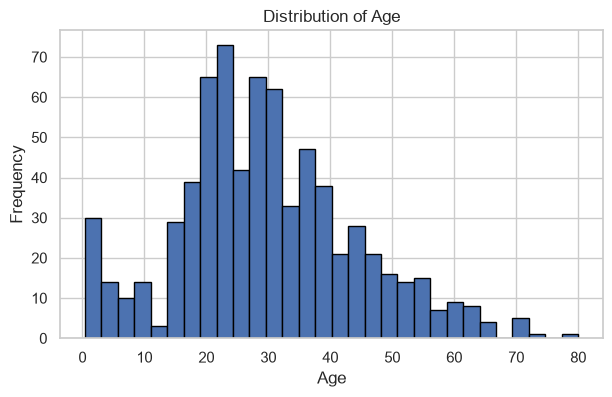

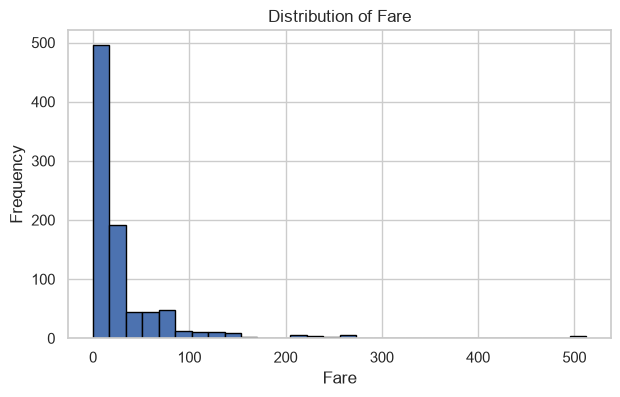

In [9]:
num_cols = ["Age", "Fare"]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

The age distribution is concentrated around young and middle-aged passengers. The fare distribution is right-skewed because most passengers paid lower fares, while a smaller number paid much more.

### Outlier Inspection

A boxplot can help show unusually high or low values. Here, I check the `Fare` column.

C:\Users\USER\AppData\Local\Temp\ipykernel_16580\2454148780.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Fare"].dropna(), vert=True)


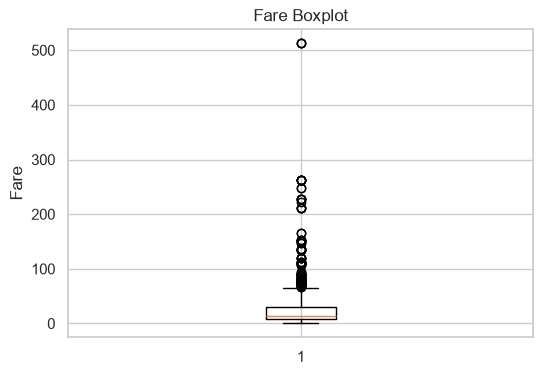

In [10]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["Fare"].dropna(), vert=True)
plt.title("Fare Boxplot")
plt.ylabel("Fare")
plt.show()

The boxplot shows several high fare values that may be treated as outliers. These values should be checked before deciding whether they need special treatment.

### Composition of Categorical Variables

Bar charts show how many records belong to each category. I check `Survived`, `Pclass`, `Sex`, and `Embarked`.

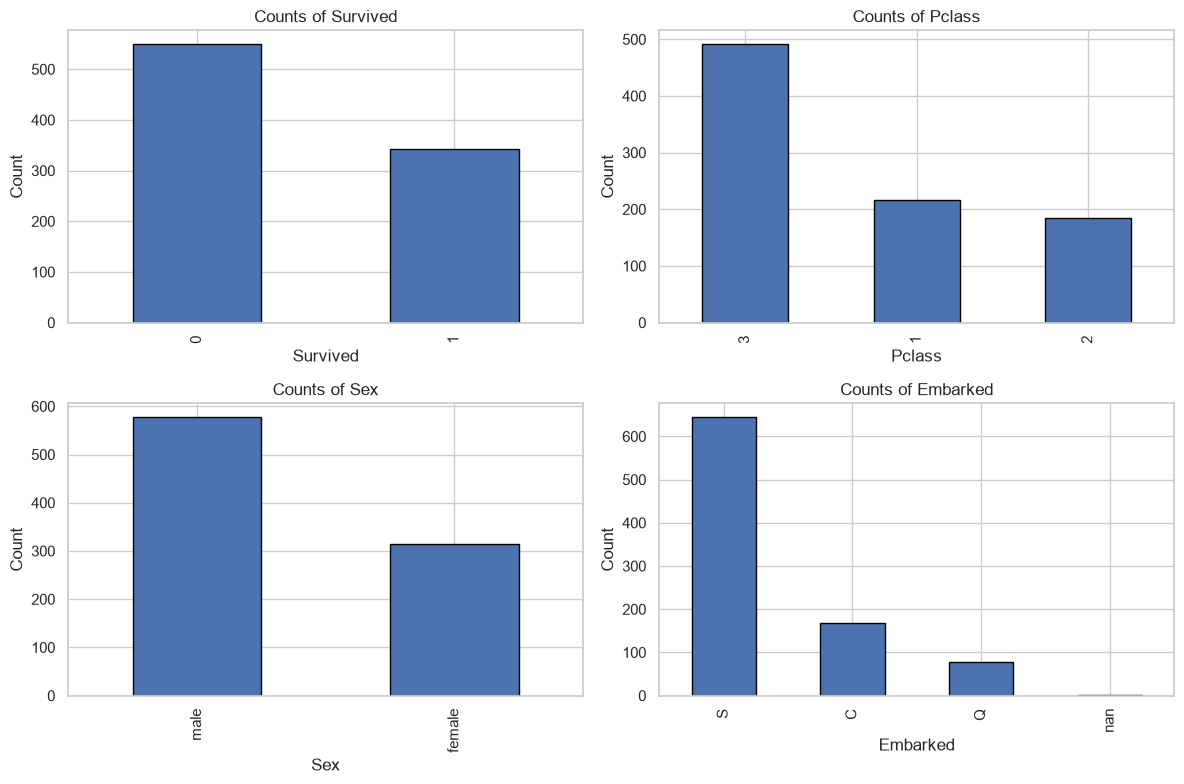

In [11]:
cat_cols = ["Survived", "Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=axes[i], edgecolor="black")
    axes[i].set_title(f"Counts of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

These charts show whether the categories are balanced. They also make it easy to notice missing values, especially in `Embarked`.

### Correlation Inspection

Correlation measures the strength and direction of a linear relationship between numerical variables. It does not prove that one variable causes another.

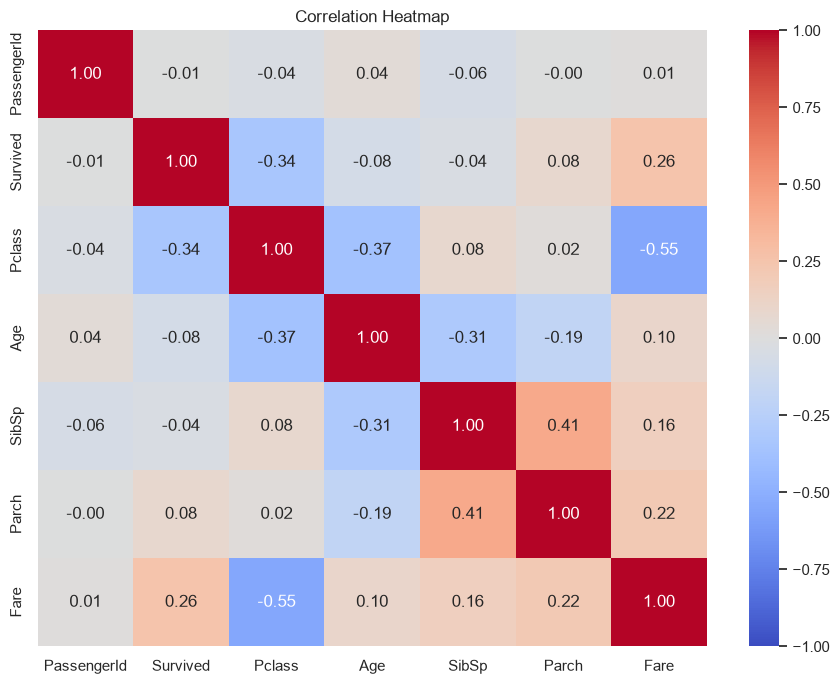

In [12]:
num_only = df.select_dtypes(include=[np.number])
corr = num_only.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap gives a quick overview of the relationships between the numerical columns. To focus on the target variable, I sort the correlations with `Survived`.

In [13]:
corr["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

### Scatter Plot: Age and Fare

A scatter plot helps show how two numerical variables are distributed together.

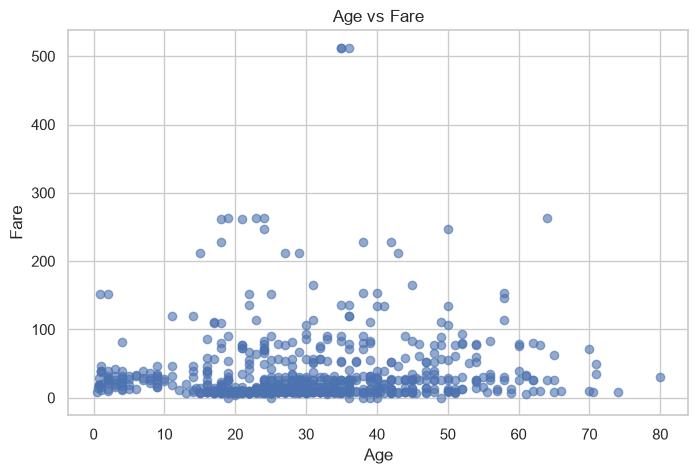

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Fare"], alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

The points do not form a clear pattern, so age and fare do not appear to have a strong linear relationship in this dataset.

## Conclusion

The Titanic dataset has 891 rows and 12 columns. It contains missing values in `Age`, `Cabin`, and `Embarked`, and the `Fare` column has some high values that may be outliers. The visual inspection also shows that the fare distribution is skewed and that there is no clear relationship between age and fare. These findings can be used as a starting point for the next data preprocessing step.